# Fingerprint Image Enhancement and Quality Assessment System

**BMDS2133 Image Processing - Mode A: Comparative and Enhancement Study**

This notebook implements the proposed classical image-processing pipeline for low-quality fingerprint images. It compares individual techniques, integrates them into a team-level hybrid method, extracts ridge/minutiae features, measures performance, and exports experimental results only when final export is explicitly enabled.

| Contribution | Technique implemented |
|---|---|
| Shared team preprocessing | Loading, grayscale conversion, common resize, controlled degradation/reference preparation, dtype/intensity handling and reproducible random seed |
| Team baseline | Simple Global Histogram Equalisation baseline |
| Member 1 | Image Restoration and Local Contrast Enhancement using Wiener Filtering and CLAHE |
| Member 2 | Multi-orientation Gabor ridge enhancement |
| Member 3 | Fingerprint segmentation, Sauvola thresholding and morphology |
| Member 4 | Skeletonisation, crossing-number minutiae extraction and evaluation |
| Team | Hybrid pipeline, batch dashboard, optional SVM quality assessment and reporting |

**Important evaluation rule:** full-reference MSE, PSNR and SSIM require aligned clean and degraded images. Therefore, controlled degradation is applied to clean SOCOFing `Real` images. The SOCOFing `Altered` images may be used later for qualitative/application testing, but they are not treated as pixel-perfect ground truth.

**Dataset roles:** SOCOFing `Real` is the reference source for controlled quantitative experiments. `Altered-Easy`, `Altered-Medium` and `Altered-Hard` are reserved for later qualitative/application testing.


## 1. Environment check

Create the supplied Conda environment before running this notebook. The environment pins NumPy 1.26.4 to avoid the NumPy 1.x/2.x binary-compatibility error that can occur in an existing Anaconda installation.

In [ ]:
from pathlib import Path
from time import perf_counter
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib

if "get_ipython" not in globals():
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
from PIL import Image
from scipy import ndimage as ndi, signal

from skimage import exposure, feature, filters, morphology, transform
from skimage.draw import ellipse
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity
from skimage.util import img_as_float

from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import joblib

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")

try:
    from IPython.display import display, Markdown
except ImportError:
    Markdown = str

    def display(value):
        print(value)

print("Environment loaded successfully")
print(f"NumPy: {np.__version__} | pandas: {pd.__version__}")


## 2. Project configuration and dataset

Download SOCOFing from: <https://www.kaggle.com/datasets/ruizgara/socofing>

Extract it so this structure exists once:

```text
data/SOCOFing/Real/
data/SOCOFing/Altered/Altered-Easy/
data/SOCOFing/Altered/Altered-Medium/
data/SOCOFing/Altered/Altered-Hard/
```

The quantitative experiment uses aligned `Real` references with controlled degradation. The `Altered` folders are kept for later qualitative/application testing and are not used for raw Real-vs-Altered MSE, PSNR or SSIM.

The assignment specification states that an external dataset should be cited rather than included in the submitted ZIP. If the dataset is missing, the notebook uses clearly labelled synthetic ridge images only to verify that the code runs. Synthetic results must not be reported as final experimental evidence.


In [ ]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name != "Fingerprint_Enhancement_Project" and (PROJECT_ROOT / "Fingerprint_Enhancement_Project").exists():
    PROJECT_ROOT = PROJECT_ROOT / "Fingerprint_Enhancement_Project"

DATA_ROOT = PROJECT_ROOT / "data" / "SOCOFing"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = (256, 256)
DEVELOPMENT_MODE = True
DEVELOPMENT_SAMPLE_IMAGES = 24
FINAL_EVALUATION_MAX_IMAGES = None  # None means use all available SOCOFing Real images.
MAX_BATCH_IMAGES = DEVELOPMENT_SAMPLE_IMAGES if DEVELOPMENT_MODE else FINAL_EVALUATION_MAX_IMAGES
RUNTIME_BENCHMARK_SAMPLE_SIZE = 50
REFERENCE_SET_MAX_IMAGES = (
    max(DEVELOPMENT_SAMPLE_IMAGES, RUNTIME_BENCHMARK_SAMPLE_SIZE)
    if DEVELOPMENT_MODE
    else FINAL_EVALUATION_MAX_IMAGES
)
RUN_RUNTIME_BENCHMARK = False
EXPORT_FINAL_RESULTS = False
RUN_OPTIONAL_SVM = False
SAVE_OPTIONAL_SVM_MODEL = False
RANDOM_SEED = 42
SUPPORTED_EXTENSIONS = {".bmp", ".png", ".jpg", ".jpeg", ".tif", ".tiff"}


def find_named_image_folder(root: Path, folder_name: str):
    """Find the first named folder that actually contains supported images."""
    if not root.exists():
        return None
    candidates = [root] if root.name.lower() == folder_name.lower() else []
    candidates.extend(p for p in root.rglob("*") if p.is_dir() and p.name.lower() == folder_name.lower())
    for folder in candidates:
        if any(p.suffix.lower() in SUPPORTED_EXTENSIONS for p in folder.iterdir() if p.is_file()):
            return folder
    return None


def list_image_files(folder):
    folder = None if folder is None else Path(folder)
    if folder is None or not folder.exists():
        return []
    return sorted(p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS)


REAL_DIR = find_named_image_folder(DATA_ROOT, "Real")
ALTERED_ROOT = DATA_ROOT / "Altered"
ALTERED_DIRS = {
    "Altered-Easy": ALTERED_ROOT / "Altered-Easy",
    "Altered-Medium": ALTERED_ROOT / "Altered-Medium",
    "Altered-Hard": ALTERED_ROOT / "Altered-Hard",
}

real_paths = list_image_files(REAL_DIR)
altered_paths = {name: list_image_files(path) for name, path in ALTERED_DIRS.items()}
USING_DEMO_DATA = len(real_paths) == 0

print(f"Project root : {PROJECT_ROOT}")
print(f"Dataset root : {DATA_ROOT}")
print(f"Real images  : {len(real_paths)}")
for altered_name, paths in altered_paths.items():
    print(f"{altered_name:15s}: {len(paths)}")
print(f"Development mode: {DEVELOPMENT_MODE} | MAX_BATCH_IMAGES: {MAX_BATCH_IMAGES}")
if USING_DEMO_DATA:
    print("WARNING: SOCOFing was not found. Synthetic DEMO images will be used; do not report them as final results.")
else:
    print("SOCOFing detected successfully.")


## 3. Image loading and controlled degradation

The synthetic degradation combines blur, sensor noise, reduced contrast, uneven illumination and a partial smudge. A fixed seed makes the experiment reproducible.

In [ ]:
def normalise_image(image, low_percentile=1.0, high_percentile=99.0):
    """Robustly scale a grayscale image to [0, 1]."""
    image = np.asarray(image, dtype=np.float32)
    low, high = np.percentile(image, [low_percentile, high_percentile])
    if high - low < 1e-8:
        return np.clip(image, 0.0, 1.0)
    return np.clip((image - low) / (high - low), 0.0, 1.0)


def load_grayscale(path, output_size=IMAGE_SIZE):
    """Load, convert to grayscale and resize without changing the aspect ratio by cropping."""
    with Image.open(path) as pil_image:
        image = np.asarray(pil_image.convert("L"), dtype=np.float32) / 255.0
    image = transform.resize(image, output_size, anti_aliasing=True, preserve_range=True)
    return normalise_image(image)


def synthetic_fingerprint(size=256, seed=0):
    """Generate a loop-like ridge image for code testing only."""
    rng = np.random.default_rng(seed)
    y, x = np.mgrid[-1:1:complex(size), -1:1:complex(size)]
    x_shift = x + 0.08 * np.sin(seed)
    y_shift = y + 0.20
    radius = np.sqrt((0.85 * x_shift) ** 2 + y_shift**2)
    angle = np.arctan2(y_shift, x_shift)
    phase = 72 * radius + 5.5 * np.sin(2 * angle) + 2.0 * x
    ridges = 0.5 + 0.45 * np.cos(phase)

    mask = (x / 0.83) ** 2 + ((y + 0.02) / 0.96) ** 2 <= 1
    image = np.where(mask, ridges, 1.0)
    image += rng.normal(0, 0.012, image.shape)
    image = ndi.gaussian_filter(image, sigma=0.55)
    return np.clip(image, 0.0, 1.0)


def make_reference_set(max_images=REFERENCE_SET_MAX_IMAGES):
    """Load real references or create a reproducible demonstration set."""
    if real_paths:
        selected = real_paths if max_images is None else real_paths[:max(0, int(max_images))]
        return [(path.name, load_grayscale(path)) for path in selected]
    demo_count = 12 if max_images is None else min(12, max(1, int(max_images)))
    return [(f"SYNTHETIC_DEMO_{index:02d}", synthetic_fingerprint(seed=index)) for index in range(demo_count)]


def simulate_degradation(reference, severity=0.55, seed=RANDOM_SEED):
    """Create an aligned low-quality input for quantitative evaluation."""
    severity = float(np.clip(severity, 0.0, 1.0))
    rng = np.random.default_rng(seed)
    image = np.asarray(reference, dtype=np.float32).copy()

    # Optical/sensor blur.
    image = ndi.gaussian_filter(image, sigma=0.35 + 1.8 * severity)

    # Reduced dynamic range plus an illumination gradient.
    image = 0.5 + (image - 0.5) * (1.0 - 0.58 * severity)
    yy, xx = np.mgrid[0:image.shape[0], 0:image.shape[1]]
    illumination = 1.0 + 0.16 * severity * np.sin(2 * np.pi * xx / image.shape[1])
    image *= illumination

    # Gaussian and sparse impulse noise.
    image += rng.normal(0.0, 0.018 + 0.055 * severity, image.shape)
    impulse_mask = rng.random(image.shape)
    image[impulse_mask < 0.0015 * severity] = 0.0
    image[impulse_mask > 1.0 - 0.0015 * severity] = 1.0

    # Partial smudge/occlusion.
    if severity >= 0.35:
        smudge = np.zeros_like(image, dtype=bool)
        centre_r = int(image.shape[0] * (0.52 + rng.uniform(-0.10, 0.10)))
        centre_c = int(image.shape[1] * (0.52 + rng.uniform(-0.10, 0.10)))
        rr, cc = ellipse(
            centre_r,
            centre_c,
            max(3, int(image.shape[0] * 0.035 * severity)),
            max(5, int(image.shape[1] * 0.10 * severity)),
            shape=image.shape,
            rotation=float(rng.uniform(-0.8, 0.8)),
        )
        smudge[rr, cc] = True
        blurred_patch = ndi.gaussian_filter(image, sigma=3.0 + 2.0 * severity)
        image[smudge] = blurred_patch[smudge]

    return np.clip(image, 0.0, 1.0)


reference_set = make_reference_set()
sample_name, sample_reference = reference_set[0]
sample_degraded = simulate_degradation(sample_reference, severity=0.55, seed=RANDOM_SEED)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sample_reference, cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"Reference\n{sample_name}")
axes[1].imshow(sample_degraded, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Controlled low-quality input")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

## 4. Member 1 - image restoration and local contrast enhancement

Member 1 final methodology is **Image Restoration and Local Contrast Enhancement using Wiener Filtering and CLAHE**.

The comparison is intentionally limited to:

- **CLAHE only:** Member 1 baseline for local contrast enhancement without restoration.
- **Wiener + CLAHE:** Member 1 final methodology, where Wiener restoration is applied before CLAHE.

CLAHE-only is not Member 1's final method. It is retained only to show what changes when image restoration is added. Removed variants such as Wiener + CLAHE + Unsharp, Median + CLAHE and CLAHE + Unsharp are not part of the Member 1 experimental comparison.

The result should be interpreted through MSE, PSNR, SSIM and ridge coherence. If the metrics disagree, preserve the trade-off rather than claiming that Wiener + CLAHE is better without support.


In [ ]:
def apply_clahe(image, clip_limit=0.025, kernel_size=(32, 32)):
    """Apply CLAHE to a normalised image."""
    return normalise_image(
        exposure.equalize_adapthist(
            normalise_image(image),
            clip_limit=float(clip_limit),
            kernel_size=kernel_size,
        )
    )


def member1_clahe_baseline(image, clip_limit=0.025):
    """Baseline local contrast enhancement without an explicit restoration stage."""
    return apply_clahe(image, clip_limit=clip_limit)


def member1_wiener_clahe(image, clip_limit=0.020, window_size=5):
    """Member 1 final method: Wiener restoration followed by CLAHE."""
    restored = signal.wiener(normalise_image(image), mysize=max(3, int(window_size)))
    return apply_clahe(restored, clip_limit=clip_limit)


member1_sample_outputs = {
    "CLAHE baseline": member1_clahe_baseline(sample_degraded),
    "Wiener + CLAHE": member1_wiener_clahe(sample_degraded),
}
sample_member1 = member1_sample_outputs["Wiener + CLAHE"]

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
panels = [("Degraded input", sample_degraded), *member1_sample_outputs.items()]
for axis, (title, image) in zip(axes, panels):
    axis.imshow(image, cmap="gray", vmin=0, vmax=1)
    axis.set_title(title)
    axis.axis("off")
fig.suptitle("Member 1 restoration and CLAHE comparison", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()


## 5. Member 2 - multi-orientation Gabor enhancement

A bank of Gabor filters responds to ridge patterns at several orientations. The strongest orientation response is fused with the CLAHE image. This is more robust than applying a single fixed orientation to the entire fingerprint.

In [ ]:
def multi_orientation_gabor(image, frequency=0.115, orientations=8, blend=0.35):
    """Enhance ridge energy with a multi-orientation Gabor bank."""
    base = normalise_image(image)
    inverted = 1.0 - base
    magnitudes = []
    for theta in np.linspace(0, np.pi, int(orientations), endpoint=False):
        real, imaginary = filters.gabor(inverted, frequency=float(frequency), theta=float(theta))
        magnitudes.append(np.hypot(real, imaginary))
    ridge_energy = normalise_image(np.max(np.stack(magnitudes, axis=0), axis=0))

    # Convert high ridge energy back to dark ridges and preserve part of the original intensity structure.
    ridge_image = 1.0 - ridge_energy
    fused = (1.0 - float(blend)) * base + float(blend) * ridge_image
    return normalise_image(fused), ridge_energy


sample_gabor, sample_ridge_energy = multi_orientation_gabor(sample_member1)


## 6. Member 3 - segmentation, thresholding and morphology

Local variance is used to isolate the fingerprint area. Sauvola thresholding extracts dark ridges under uneven illumination, while opening, closing and small-object removal reconnect ridge fragments and suppress isolated noise.

C:\Users\User\AppData\Local\Temp\ipykernel_23268\2087948754.py:12: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = morphology.remove_small_holes(mask, 800)
C:\Users\User\AppData\Local\Temp\ipykernel_23268\2087948754.py:13: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = morphology.remove_small_objec

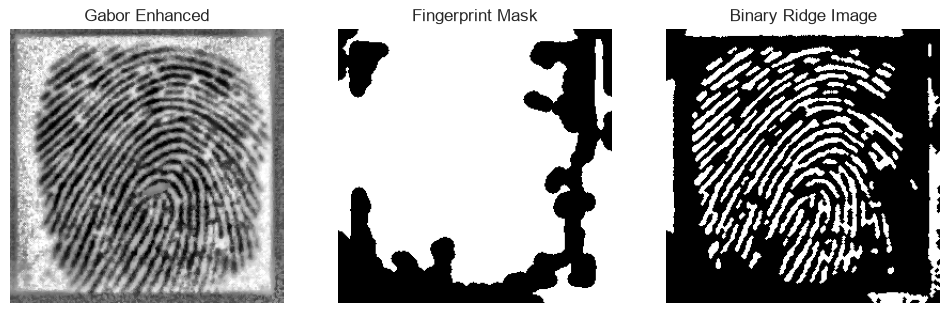

In [16]:
def fingerprint_mask(image, block_size=17):
    image = normalise_image(image)

    local_mean = ndi.uniform_filter(image, size=block_size, mode="reflect")
    local_mean_sq = ndi.uniform_filter(image**2, size=block_size, mode="reflect")
    local_std = np.sqrt(np.maximum(local_mean_sq - local_mean**2, 0.0))

    threshold = max(0.018, float(np.percentile(local_std, 48)))
    mask = local_std > threshold

    mask = morphology.closing(mask, morphology.disk(7))
    mask = morphology.remove_small_holes(mask, 800)
    mask = morphology.remove_small_objects(mask, 700)

    return mask


def segment_and_restore_ridges(image, window_size=25, sauvola_k=0.16):
    image = normalise_image(image)

    mask = fingerprint_mask(image)

    threshold_surface = filters.threshold_sauvola(
        image,
        window_size=int(window_size),
        k=float(sauvola_k)
    )

    ridges = (image < threshold_surface) & mask

    ridges = morphology.opening(ridges, morphology.disk(1))
    ridges = morphology.closing(ridges, morphology.disk(1))
    ridges = morphology.remove_small_objects(ridges, 12)
    ridges = morphology.remove_small_holes(ridges, 10)

    return ridges, mask


sample_binary, sample_mask = segment_and_restore_ridges(sample_gabor)


plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(sample_gabor, cmap="gray")
plt.title("Gabor Enhanced")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sample_mask, cmap="gray")
plt.title("Fingerprint Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sample_binary, cmap="gray")
plt.title("Binary Ridge Image")
plt.axis("off")

plt.show()

## 7. Member 4 - thinning and crossing-number minutiae extraction

Ridges are reduced to one-pixel-wide skeletons. For each skeleton pixel, the crossing number around its eight neighbours identifies ridge endings (CN = 1) and bifurcations (CN = 3). Points close to the segmented boundary or to another detected point are removed to reduce false minutiae.

C:\Users\User\AppData\Local\Temp\ipykernel_23268\1961626266.py:39: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  valid &= morphology.binary_erosion(mask, morphology.disk(erosion_radius))


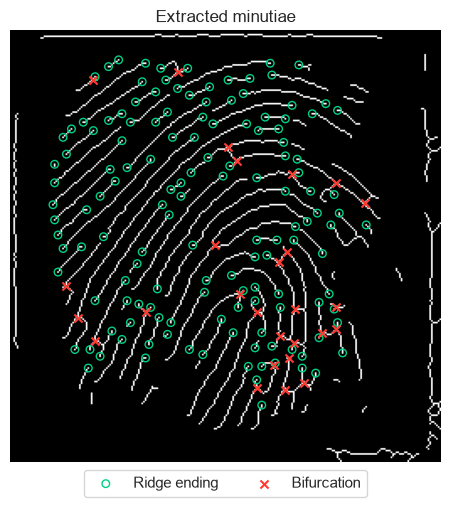

Ridge endings: 141 | Bifurcations: 27


In [18]:
def thin_ridges(binary_ridges):
    return morphology.thin(np.asarray(binary_ridges, dtype=bool))


def _suppress_nearby_points(points, minimum_distance=7):
    kept = []
    for row, col in points:
        if all((row - kr) ** 2 + (col - kc) ** 2 >= minimum_distance**2 for kr, kc in kept):
            kept.append((int(row), int(col)))
    return np.asarray(kept, dtype=int).reshape(-1, 2)


def extract_minutiae(skeleton, mask=None, border_margin=12, minimum_distance=7):
    """Return arrays of ridge endings and bifurcations using crossing numbers."""
    skeleton = np.asarray(skeleton, dtype=np.uint8)
    padded = np.pad(skeleton, 1)
    neighbours = [
        padded[:-2, 1:-1],      # N
        padded[:-2, 2:],        # NE
        padded[1:-1, 2:],       # E
        padded[2:, 2:],         # SE
        padded[2:, 1:-1],       # S
        padded[2:, :-2],        # SW
        padded[1:-1, :-2],      # W
        padded[:-2, :-2],       # NW
    ]
    transitions = sum(np.abs(neighbours[i].astype(int) - neighbours[(i + 1) % 8].astype(int)) for i in range(8))
    crossing_number = transitions / 2.0
    ending_map = (skeleton == 1) & (crossing_number == 1)
    bifurcation_map = (skeleton == 1) & (crossing_number == 3)

    valid = np.ones_like(skeleton, dtype=bool)
    valid[:border_margin, :] = False
    valid[-border_margin:, :] = False
    valid[:, :border_margin] = False
    valid[:, -border_margin:] = False
    if mask is not None:
        erosion_radius = max(3, border_margin // 2)
        valid &= morphology.binary_erosion(mask, morphology.disk(erosion_radius))

    endings = _suppress_nearby_points(np.argwhere(ending_map & valid), minimum_distance)
    bifurcations = _suppress_nearby_points(np.argwhere(bifurcation_map & valid), minimum_distance)
    return endings, bifurcations


def minutiae_overlay(image, endings, bifurcations, title="Extracted minutiae"):
    fig, ax = plt.subplots(figsize=(5.2, 5.2))
    ax.imshow(image, cmap="gray", vmin=0, vmax=1)
    if len(endings):
        ax.scatter(endings[:, 1], endings[:, 0], s=30, facecolors="none", edgecolors="#00d084", label="Ridge ending")
    if len(bifurcations):
        ax.scatter(bifurcations[:, 1], bifurcations[:, 0], s=34, marker="x", c="#ff3b30", label="Bifurcation")
    ax.set_title(title)
    ax.axis("off")
    if len(endings) or len(bifurcations):
        ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.10), ncol=2, frameon=True)
    fig.tight_layout()
    return fig, ax


sample_skeleton = thin_ridges(sample_binary)
sample_endings, sample_bifurcations = extract_minutiae(sample_skeleton, sample_mask)
_ = minutiae_overlay(sample_skeleton, sample_endings, sample_bifurcations)
plt.show()
print(f"Ridge endings: {len(sample_endings)} | Bifurcations: {len(sample_bifurcations)}")

## 8. Integrated pipeline and quantitative metrics

The integrated comparison keeps individual member work separate from shared team preprocessing and team-level baselines.

The compared grayscale outputs are:

- **Degraded input:** controlled low-quality input.
- **Global HE baseline:** simple team-level histogram equalisation baseline.
- **Member 1 CLAHE baseline:** CLAHE only.
- **Member 1 Wiener + CLAHE:** Member 1 final methodology.
- **Member 2 Gabor:** multi-orientation Gabor enhancement.
- **Hybrid:** team-level combined experiment.

The following measurements are reported:

- **MSE:** lower is better.
- **PSNR:** higher is better and is stated in decibels (dB).
- **SSIM:** higher is better; 1 represents identical structure.
- **Orientation coherence:** higher values indicate more consistent local ridge direction.
- **Keypoint match score:** percentage of cross-checked ORB matches relative to the smaller detected keypoint set. It is a matching score, not classification accuracy.
- **Runtime:** lower is faster.

For MSE, PSNR and SSIM, the reference and candidate are only clipped to the same `[0, 1]` range. They are not independently contrast-normalised immediately before metric calculation.


In [ ]:
def orientation_coherence(image, mask=None, smoothing_sigma=2.0):
    image = normalise_image(image)
    gx = filters.sobel_h(image)
    gy = filters.sobel_v(image)
    gxx = ndi.gaussian_filter(gx * gx, smoothing_sigma)
    gyy = ndi.gaussian_filter(gy * gy, smoothing_sigma)
    gxy = ndi.gaussian_filter(gx * gy, smoothing_sigma)
    coherence = np.sqrt((gxx - gyy) ** 2 + 4.0 * gxy**2) / (gxx + gyy + 1e-8)
    if mask is None or not np.any(mask):
        return float(np.mean(coherence))
    return float(np.mean(coherence[np.asarray(mask, dtype=bool)]))


def keypoint_match_score(reference, candidate, maximum_keypoints=300):
    """Calculate a reproducible ORB matching score in the range 0-100."""
    try:
        orb_ref = feature.ORB(n_keypoints=maximum_keypoints, fast_threshold=0.06)
        orb_ref.detect_and_extract(normalise_image(reference))
        orb_candidate = feature.ORB(n_keypoints=maximum_keypoints, fast_threshold=0.06)
        orb_candidate.detect_and_extract(normalise_image(candidate))
        matches = feature.match_descriptors(
            orb_ref.descriptors,
            orb_candidate.descriptors,
            cross_check=True,
            max_ratio=0.80,
        )
        denominator = max(1, min(len(orb_ref.keypoints), len(orb_candidate.keypoints)))
        return float(100.0 * len(matches) / denominator)
    except (RuntimeError, ValueError):
        return 0.0


def metric_image(image):
    """Prepare an already aligned [0, 1] image for full-reference metrics without contrast re-normalising it."""
    image = np.asarray(image, dtype=np.float32)
    image = np.nan_to_num(image, nan=0.0, posinf=1.0, neginf=0.0)
    return np.clip(image, 0.0, 1.0)


def global_histogram_equalisation(image):
    """Simple team-level baseline using global histogram equalisation only."""
    return metric_image(exposure.equalize_hist(metric_image(image)))


def evaluate_grayscale(reference, candidate, mask, runtime_seconds=np.nan):
    reference = metric_image(reference)
    candidate = metric_image(candidate)
    if reference.shape != candidate.shape:
        raise ValueError(f"Metric images must be aligned and equal-sized; got {reference.shape} and {candidate.shape}.")
    return {
        "MSE": float(mean_squared_error(reference, candidate)),
        "PSNR (dB)": float(peak_signal_noise_ratio(reference, candidate, data_range=1.0)),
        "SSIM": float(structural_similarity(reference, candidate, data_range=1.0)),
        "Coherence": orientation_coherence(candidate, mask),
        "Match score (%)": keypoint_match_score(reference, candidate),
        "Runtime (s)": float(runtime_seconds),
    }


def run_comparison(reference, severity=0.55, seed=RANDOM_SEED):
    """Run comparable grayscale methods and the complete binary-feature pipeline."""
    degraded = simulate_degradation(reference, severity=severity, seed=seed)
    reference_mask = fingerprint_mask(reference)

    outputs = {"Degraded input": degraded}
    runtimes = {"Degraded input": 0.0}

    start = perf_counter()
    outputs["Global HE baseline"] = global_histogram_equalisation(degraded)
    runtimes["Global HE baseline"] = perf_counter() - start

    start = perf_counter()
    outputs["M1 CLAHE baseline"] = member1_clahe_baseline(degraded)
    runtimes["M1 CLAHE baseline"] = perf_counter() - start

    start = perf_counter()
    member1_final = member1_wiener_clahe(degraded)
    outputs["M1 Wiener + CLAHE"] = member1_final
    runtimes["M1 Wiener + CLAHE"] = perf_counter() - start

    start = perf_counter()
    gabor_input = apply_clahe(degraded, clip_limit=0.012)
    gabor_only, _ = multi_orientation_gabor(gabor_input, blend=0.58)
    outputs["Gabor"] = gabor_only
    runtimes["Gabor"] = perf_counter() - start

    start = perf_counter()
    hybrid_gray, ridge_energy = multi_orientation_gabor(member1_final, blend=0.30)
    outputs["Hybrid"] = hybrid_gray
    runtimes["Hybrid"] = perf_counter() - start

    binary, mask = segment_and_restore_ridges(hybrid_gray)
    skeleton = thin_ridges(binary)
    endings, bifurcations = extract_minutiae(skeleton, mask)

    metric_rows = []
    for method, output in outputs.items():
        row = {"Method": method}
        row.update(evaluate_grayscale(reference, output, reference_mask, runtimes[method]))
        metric_rows.append(row)

    return {
        "reference": reference,
        "degraded": degraded,
        "outputs": outputs,
        "ridge_energy": ridge_energy,
        "binary": binary,
        "mask": mask,
        "skeleton": skeleton,
        "endings": endings,
        "bifurcations": bifurcations,
        "metrics": pd.DataFrame(metric_rows),
    }


sample_result = run_comparison(sample_reference, severity=0.55, seed=RANDOM_SEED)
display(sample_result["metrics"].round(4))


## 9. Processing dashboard

The dashboard summarises the complete pipeline for one image. In Jupyter, the optional controls permit the image and degradation severity to be changed interactively.

In [ ]:
def plot_pipeline_dashboard(result, sample_title="Fingerprint enhancement result"):
    panels = [
        (result["reference"], "Clean reference", "gray"),
        (result["degraded"], "Low-quality input", "gray"),
        (result["outputs"]["M1 Wiener + CLAHE"], "Member 1: Wiener + CLAHE", "gray"),
        (result["outputs"]["Gabor"], "Member 2: Gabor", "gray"),
        (result["binary"], "Member 3: Restored ridges", "gray"),
        (result["skeleton"], "Member 4: Skeleton", "gray"),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    for axis, (image, title, colourmap) in zip(axes.ravel(), panels):
        axis.imshow(image, cmap=colourmap, vmin=0, vmax=1)
        axis.set_title(title)
        axis.axis("off")
    fig.suptitle(sample_title, fontsize=16, fontweight="bold")
    fig.tight_layout()
    return fig


dashboard_figure = plot_pipeline_dashboard(sample_result, sample_title=sample_name)
plt.show()


try:
    import ipywidgets as widgets
    from IPython.display import clear_output

    def interactive_dashboard(image_index=0, severity=0.55):
        clear_output(wait=True)
        image_index = int(np.clip(image_index, 0, len(reference_set) - 1))
        name, reference = reference_set[image_index]
        result = run_comparison(reference, severity=float(severity), seed=RANDOM_SEED + image_index)
        display(result["metrics"].round(4))
        plot_pipeline_dashboard(result, sample_title=name)
        plt.show()

    widgets.interact(
        interactive_dashboard,
        image_index=widgets.IntSlider(value=0, min=0, max=max(0, len(reference_set) - 1), step=1),
        severity=widgets.FloatSlider(value=0.55, min=0.2, max=0.9, step=0.05),
    )
except Exception:
    print("ipywidgets is optional; run plot_pipeline_dashboard(sample_result) for the static dashboard.")


## 10. Batch experiment and critical comparison

Every method is tested on the same reference images and degradation settings. The summary uses the mean and standard deviation across the active batch.

Development mode uses a small configurable sample for debugging and fast experimentation. Final evaluation mode can use a larger configurable batch, including all 6000 SOCOFing `Real` images when `FINAL_EVALUATION_MAX_IMAGES = None` and runtime is acceptable.

No weighted overall score is created here. MSE, PSNR, SSIM and ridge coherence are interpreted separately so that real trade-offs remain visible. If Global HE achieves the best PSNR or MSE, that result should remain in the comparison.


In [ ]:
def select_reference_batch(references, max_images=MAX_BATCH_IMAGES):
    if max_images is None:
        return list(references)
    return list(references[:max(0, int(max_images))])


def run_batch_experiment(references, severities=(0.35, 0.55, 0.75), progress=True):
    rows = []
    total = len(references)
    for index, (name, reference) in enumerate(references):
        severity = float(severities[index % len(severities)])
        result = run_comparison(reference, severity=severity, seed=RANDOM_SEED + index)
        frame = result["metrics"].copy()
        frame.insert(0, "Image", name)
        frame.insert(1, "Severity", severity)
        frame["Ridge endings"] = len(result["endings"])
        frame["Bifurcations"] = len(result["bifurcations"])
        rows.append(frame)
        if progress:
            print(f"Processed {index + 1:02d}/{total:02d}: {name}")
    return pd.concat(rows, ignore_index=True)


active_batch_references = select_reference_batch(reference_set, MAX_BATCH_IMAGES)
print(
    f"Active batch: {len(active_batch_references)} image(s) "
    f"({'development' if DEVELOPMENT_MODE else 'final evaluation'} mode)"
)

batch_metrics = run_batch_experiment(active_batch_references)
summary_metrics = (
    batch_metrics.groupby("Method", as_index=False)
    .agg(
        MSE_mean=("MSE", "mean"),
        MSE_std=("MSE", "std"),
        PSNR_mean=("PSNR (dB)", "mean"),
        PSNR_std=("PSNR (dB)", "std"),
        SSIM_mean=("SSIM", "mean"),
        SSIM_std=("SSIM", "std"),
        Coherence_mean=("Coherence", "mean"),
        Coherence_std=("Coherence", "std"),
        Match_mean=("Match score (%)", "mean"),
        Match_std=("Match score (%)", "std"),
        Runtime_mean=("Runtime (s)", "mean"),
        Runtime_std=("Runtime (s)", "std"),
    )
)

method_order = [
    "Degraded input",
    "Global HE baseline",
    "M1 CLAHE baseline",
    "M1 Wiener + CLAHE",
    "Gabor",
    "Hybrid",
]
summary_metrics["Method"] = pd.Categorical(summary_metrics["Method"], categories=method_order, ordered=True)
summary_metrics = summary_metrics.sort_values("Method").reset_index(drop=True)
summary_metrics["Method"] = summary_metrics["Method"].astype(str)

enhancement_summary = summary_metrics[summary_metrics["Method"] != "Degraded input"].copy()
metric_leaders = pd.DataFrame(
    [
        {
            "Metric": "MSE",
            "Direction": "lower is better",
            "Best method": enhancement_summary.loc[enhancement_summary["MSE_mean"].idxmin(), "Method"],
            "Value": enhancement_summary["MSE_mean"].min(),
        },
        {
            "Metric": "PSNR (dB)",
            "Direction": "higher is better",
            "Best method": enhancement_summary.loc[enhancement_summary["PSNR_mean"].idxmax(), "Method"],
            "Value": enhancement_summary["PSNR_mean"].max(),
        },
        {
            "Metric": "SSIM",
            "Direction": "higher is better",
            "Best method": enhancement_summary.loc[enhancement_summary["SSIM_mean"].idxmax(), "Method"],
            "Value": enhancement_summary["SSIM_mean"].max(),
        },
        {
            "Metric": "Coherence",
            "Direction": "higher is better",
            "Best method": enhancement_summary.loc[enhancement_summary["Coherence_mean"].idxmax(), "Method"],
            "Value": enhancement_summary["Coherence_mean"].max(),
        },
    ]
)

print("Batch summary (mean and standard deviation):")
display(summary_metrics.round(4))
print("Metric-specific leaders; no weighted overall score is used:")
display(metric_leaders.round(4))


In [ ]:
metric_plot_columns = ["PSNR (dB)", "SSIM", "Coherence", "Match score (%)"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for axis, metric in zip(axes.ravel(), metric_plot_columns):
    sns.barplot(
        data=batch_metrics,
        x="Method",
        y=metric,
        hue="Method",
        order=method_order,
        hue_order=method_order,
        legend=False,
        errorbar="sd",
        ax=axis,
    )
    axis.set_title(f"Mean {metric} with standard deviation")
    axis.tick_params(axis="x", rotation=25)
fig.suptitle("Comparative fingerprint enhancement results", fontsize=16, fontweight="bold")
fig.tight_layout()
plt.show()


## 11. Runtime benchmark

The runtime benchmark is a temporary development check used only to estimate practical final batch sizes. It should be run on a moderate sample such as 50 or 100 `Real` images, not on the full dataset.

The benchmark reports total runtime, approximate runtime per image and estimated runtime for 500, 1000 and 6000 images. It does not optimise algorithms and does not export final CSV/PDF results.


In [ ]:
def estimate_batch_runtime(total_seconds, sample_size, target_sizes=(500, 1000, 6000)):
    per_image = float(total_seconds) / max(1, int(sample_size))
    rows = [
        {
            "Images": int(target_size),
            "Estimated runtime (s)": per_image * int(target_size),
            "Estimated runtime (min)": per_image * int(target_size) / 60.0,
        }
        for target_size in target_sizes
    ]
    return per_image, pd.DataFrame(rows)


def run_runtime_benchmark(references, sample_size=RUNTIME_BENCHMARK_SAMPLE_SIZE):
    benchmark_references = select_reference_batch(references, min(int(sample_size), len(references)))
    start = perf_counter()
    benchmark_metrics = run_batch_experiment(benchmark_references, progress=False)
    total_seconds = perf_counter() - start
    per_image, estimates = estimate_batch_runtime(total_seconds, len(benchmark_references))
    summary = pd.DataFrame(
        [
            {
                "Benchmark sample size": len(benchmark_references),
                "Measured total runtime (s)": total_seconds,
                "Approx runtime per image (s)": per_image,
            }
        ]
    )
    return benchmark_metrics, summary, estimates


if RUN_RUNTIME_BENCHMARK:
    runtime_benchmark_metrics, runtime_benchmark_summary, runtime_benchmark_estimates = run_runtime_benchmark(
        reference_set,
        sample_size=RUNTIME_BENCHMARK_SAMPLE_SIZE,
    )
    display(runtime_benchmark_summary.round(4))
    display(runtime_benchmark_estimates.round(2))
else:
    print(
        "Runtime benchmark is configured but not run automatically. "
        "Set RUN_RUNTIME_BENCHMARK = True or call run_runtime_benchmark(reference_set, 50)."
    )


## 12. Optional Extra Effort - SVM Synthetic Quality Classification

The SVM section is frozen for the main classical image-processing cleanup. It is kept as a clearly separated optional extra-effort component and does not affect Member 1, Member 2, Member 3, Member 4, Hybrid, PSNR/MSE/SSIM comparison or method interpretation.

When intentionally enabled later, the SVM predicts **Good**, **Fair** or **Poor** quality from six image-quality features. Labels come from controlled degradation levels, so this model assesses degradation quality; it does not recognise fingerprint identity. Accuracy is only reported for the held-out controlled test set.


In [ ]:
def image_entropy(image, bins=64):
    histogram, _ = np.histogram(normalise_image(image), bins=bins, range=(0, 1), density=False)
    probabilities = histogram.astype(float) / max(1, histogram.sum())
    probabilities = probabilities[probabilities > 0]
    return float(-np.sum(probabilities * np.log2(probabilities)))


def quality_features(image):
    image = normalise_image(image)
    mask = fingerprint_mask(image)
    foreground = image[mask] if np.any(mask) else image.ravel()
    laplacian_variance = float(np.var(filters.laplace(image)))
    gradient = np.hypot(filters.sobel_h(image), filters.sobel_v(image))
    return {
        "Intensity std": float(np.std(foreground)),
        "Entropy": image_entropy(foreground),
        "Laplacian variance": laplacian_variance,
        "Gradient mean": float(np.mean(gradient[mask])) if np.any(mask) else float(np.mean(gradient)),
        "Coherence": orientation_coherence(image, mask),
        "Foreground ratio": float(np.mean(mask)),
    }


def build_quality_dataset(references):
    quality_levels = [(0.20, "Good"), (0.50, "Fair"), (0.80, "Poor")]
    rows = []
    for index, (name, reference) in enumerate(references):
        for severity, label in quality_levels:
            degraded = simulate_degradation(reference, severity=severity, seed=1000 + 10 * index + int(severity * 10))
            row = {"Image": name, "Quality": label, "Severity": severity}
            row.update(quality_features(degraded))
            rows.append(row)
    return pd.DataFrame(rows)


quality_accuracy = np.nan
quality_data = pd.DataFrame()
feature_columns = [
    "Intensity std",
    "Entropy",
    "Laplacian variance",
    "Gradient mean",
    "Coherence",
    "Foreground ratio",
]

if RUN_OPTIONAL_SVM:
    quality_data = build_quality_dataset(reference_set)
    X_train, X_test, y_train, y_test = train_test_split(
        quality_data[feature_columns],
        quality_data["Quality"],
        test_size=0.30,
        random_state=RANDOM_SEED,
        stratify=quality_data["Quality"],
    )

    quality_model = make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", C=5.0, gamma="scale", class_weight="balanced"),
    )
    quality_model.fit(X_train, y_train)
    quality_predictions = quality_model.predict(X_test)
    quality_accuracy = accuracy_score(y_test, quality_predictions)

    print(f"Controlled test-set SVM accuracy: {quality_accuracy * 100:.2f}%")
    print(classification_report(y_test, quality_predictions, zero_division=0))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        quality_predictions,
        labels=["Good", "Fair", "Poor"],
        cmap="Blues",
    )
    plt.title("SVM fingerprint-quality confusion matrix")
    plt.grid(False)
    plt.show()

    if SAVE_OPTIONAL_SVM_MODEL:
        joblib.dump({"model": quality_model, "features": feature_columns}, OUTPUT_DIR / "svm_quality_model.joblib")
    else:
        print("SVM model export disabled; existing svm_quality_model.joblib is preserved.")
else:
    print("Optional Extra Effort - SVM Synthetic Quality Classification is frozen for this cleanup task.")
    print("Set RUN_OPTIONAL_SVM = True later only when the team is ready to review the SVM separately.")


## 13. Result export

Final-looking CSV, PDF and metadata exports are disabled by default in this cleanup task. Set `EXPORT_FINAL_RESULTS = True` only after the team approves a final evaluation run.

Runtime benchmark evidence should remain temporary/development evidence and should not overwrite final-looking output files.


In [ ]:
def export_pdf_report(summary, example_result, destination):
    with PdfPages(destination) as pdf:
        # Page 1: method summary.
        fig, ax = plt.subplots(figsize=(11.69, 8.27))
        ax.axis("off")
        ax.set_title("Fingerprint Enhancement - Batch Experiment Summary", fontsize=18, fontweight="bold", pad=18)
        table_columns = ["Method", "MSE_mean", "PSNR_mean", "SSIM_mean", "Coherence_mean", "Match_mean", "Runtime_mean"]
        table_frame = summary[table_columns].copy().round(4)
        table = ax.table(cellText=table_frame.values, colLabels=table_frame.columns, cellLoc="center", loc="center")
        table.auto_set_font_size(False)
        table.set_fontsize(9)
        table.scale(1.0, 1.6)
        ax.text(
            0.5,
            0.08,
            f"Dataset mode: {'SYNTHETIC DEMO - replace with SOCOFing' if USING_DEMO_DATA else 'SOCOFing Real images with controlled degradation'}",
            ha="center",
            fontsize=10,
            color="#b42318" if USING_DEMO_DATA else "#176b3a",
        )
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

        # Page 2: pipeline images.
        fig = plot_pipeline_dashboard(example_result, sample_title="Example processing pipeline")
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

        # Page 3: metric charts.
        fig, axes = plt.subplots(2, 2, figsize=(11.69, 8.27))
        for axis, metric in zip(axes.ravel(), metric_plot_columns):
            sns.barplot(
                data=batch_metrics,
                x="Method",
                y=metric,
                hue="Method",
                order=method_order,
                hue_order=method_order,
                legend=False,
                errorbar="sd",
                ax=axis,
            )
            axis.set_title(metric)
            axis.tick_params(axis="x", rotation=25)
        fig.suptitle("Mean performance with standard deviation", fontsize=16, fontweight="bold")
        fig.tight_layout()
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)


if EXPORT_FINAL_RESULTS:
    batch_csv = OUTPUT_DIR / "batch_metrics.csv"
    summary_csv = OUTPUT_DIR / "summary_metrics.csv"
    report_pdf = OUTPUT_DIR / "fingerprint_enhancement_report.pdf"
    overlay_png = OUTPUT_DIR / "example_minutiae_overlay.png"
    experiment_json = OUTPUT_DIR / "experiment_metadata.json"

    batch_metrics.to_csv(batch_csv, index=False)
    summary_metrics.to_csv(summary_csv, index=False)
    export_pdf_report(summary_metrics, sample_result, report_pdf)

    overlay_figure, _ = minutiae_overlay(
        sample_result["skeleton"],
        sample_result["endings"],
        sample_result["bifurcations"],
        title="Example extracted minutiae",
    )
    overlay_figure.savefig(overlay_png, dpi=180, bbox_inches="tight")
    plt.close(overlay_figure)

    metadata = {
        "dataset_mode": "synthetic_demo" if USING_DEMO_DATA else "SOCOFing_real_controlled_degradation",
        "development_mode": DEVELOPMENT_MODE,
        "max_batch_images": MAX_BATCH_IMAGES,
        "number_of_reference_images": len(reference_set),
        "active_batch_images": len(active_batch_references),
        "image_size": list(IMAGE_SIZE),
        "random_seed": RANDOM_SEED,
        "member1_final_method": "Wiener + CLAHE",
        "member1_baseline": "CLAHE only",
        "team_baseline": "Global HE baseline",
        "metric_specific_leaders": metric_leaders.to_dict(orient="records"),
        "svm_controlled_test_accuracy": None if np.isnan(quality_accuracy) else float(quality_accuracy),
        "warning": "Synthetic demo measurements are not final experimental evidence." if USING_DEMO_DATA else "",
    }
    experiment_json.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

    print("Exported files:")
    for path in sorted(OUTPUT_DIR.iterdir()):
        print(f" - {path.name}")
else:
    print("Final exports are disabled. Existing output files were not overwritten by this run.")


## 14. Interpretation checklist for the report

1. Confirm that `USING_DEMO_DATA` is `False` before collecting final results.
2. Confirm whether the notebook is in development mode or final evaluation mode, and report the active batch size.
3. Report the number of SOCOFing `Real` reference images, controlled degradation levels and fixed random seed.
4. Keep `Altered-Easy`, `Altered-Medium` and `Altered-Hard` for later qualitative/application testing; do not report raw Real-vs-Altered full-reference metrics without registration.
5. Compare mean **and standard deviation**, not a single best-looking image.
6. Interpret MSE, PSNR, SSIM and ridge coherence separately; do not use a weighted overall score.
7. If metric leaders disagree, explain the trade-off instead of forcing one method to win.
8. Report Global HE as a simple team-level baseline, not as an individual member method.
9. Report CLAHE-only as Member 1's baseline and Wiener + CLAHE as Member 1's final methodology.
10. Explain the trade-off between restoration quality and runtime. Gabor filtering may improve ridge coherence but require more computation.
11. Do not rename the ORB match score as "accuracy". Only the SVM held-out classification result is an accuracy value.
12. Keep the optional SVM synthetic quality classifier separate from the main classical image-processing comparison.
13. Discuss failure cases such as severe smudging, weak ridge contrast, over-segmentation and false minutiae.
14. Link the conclusion back to the SMART objectives and state whether the quantitative improvement target was achieved.


## References

Shehu, Y. I., Ruiz-Garcia, A., Palade, V., & James, A. (2018). *Sokoto Coventry Fingerprint Dataset*. arXiv. <https://arxiv.org/abs/1807.10609>

Shehu, Y. I., Ruiz-Garcia, A., Palade, V., & James, A. (2018). *Sokoto Coventry Fingerprint Dataset (SOCOFing)* [Data set]. Kaggle. <https://www.kaggle.com/datasets/ruizgara/socofing>

Jain, A. K., Hong, L., Pankanti, S., & Bolle, R. (1997). An identity-authentication system using fingerprints. *Proceedings of the IEEE, 85*(9), 1365-1388. <https://doi.org/10.1109/5.628674>

**AI disclosure reminder:** retain the required AI usage disclosure form and describe the prompts used, the code tests performed, the dataset checks completed, and any manual modifications made by the team.